In [1]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE

from collections import Counter

# Load dataset
raw_data = pd.read_csv("../data/diabetes.csv")
selected_features = ['Pregnancies', 'Glucose', 'BMI', 'Age', 'Outcome']
selected_data = raw_data[selected_features]

In [2]:
# Preprocessing: remove outliers using IQR method
def Preprocess(rawDataset, outlier_threshold=1):
    features = list(rawDataset.columns[:-1])
    outlier_indices = []

    for feature in features:
        Q1 = np.percentile(rawDataset[feature], 25)
        Q3 = np.percentile(rawDataset[feature], 75)
        IQR = Q3 - Q1
        step = 1.5 * IQR
        outlier_indices.extend(rawDataset[(rawDataset[feature] < Q1 - step) | (rawDataset[feature] > Q3 + step)].index)

    outlier_indices = [idx for idx, count in Counter(outlier_indices).items() if count > outlier_threshold]
    rawDataset = rawDataset.drop(index=outlier_indices).reset_index(drop=True)

    dataset = rawDataset.iloc[:, :-1].values
    label = rawDataset.iloc[:, -1].values
    return dataset, label

# Clean and prepare
dataset, label = Preprocess(selected_data)

[Text(0.5, 0.875, 'x[1] <= 123.5\ngini = 0.461\nsamples = 575\nvalue = [368, 207]'),
 Text(0.25, 0.625, 'x[3] <= 28.5\ngini = 0.303\nsamples = 327\nvalue = [266, 61]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[2] <= 30.95\ngini = 0.167\nsamples = 185\nvalue = [168, 17]'),
 Text(0.0625, 0.125, 'gini = 0.038\nsamples = 102\nvalue = [100, 2]'),
 Text(0.1875, 0.125, 'gini = 0.296\nsamples = 83\nvalue = [68, 15]'),
 Text(0.375, 0.375, 'x[2] <= 26.35\ngini = 0.428\nsamples = 142\nvalue = [98, 44]'),
 Text(0.3125, 0.125, 'gini = 0.067\nsamples = 29\nvalue = [28, 1]'),
 Text(0.4375, 0.125, 'gini = 0.471\nsamples = 113\nvalue = [70, 43]'),
 Text(0.75, 0.625, 'x[2] <= 29.95\ngini = 0.484\nsamples = 248\nvalue = [102, 146]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[3] <= 26.0\ngini = 0.419\nsamples = 67\nvalue = [47, 20]'),
 Text(0.5625, 0.125, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]'),
 Text(0.6875, 0.125, 'gini = 0.486\nsamples = 48\nvalue = [28, 20]'),
 Text(0.875,

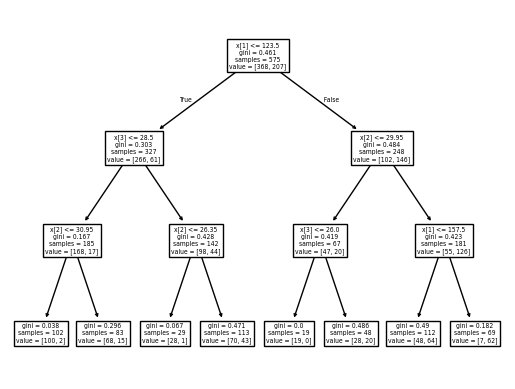

In [3]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# print(label)
X_train, X_test, Y_train, Y_test = train_test_split(dataset, label, random_state=0)
# clf = DecisionTreeClassifier(max_depth = 2, random_state = 0)
clf = DecisionTreeClassifier(splitter = "best", max_depth=3, min_samples_leaf=10)
clf.fit(X_train, Y_train)
tree.plot_tree(clf)


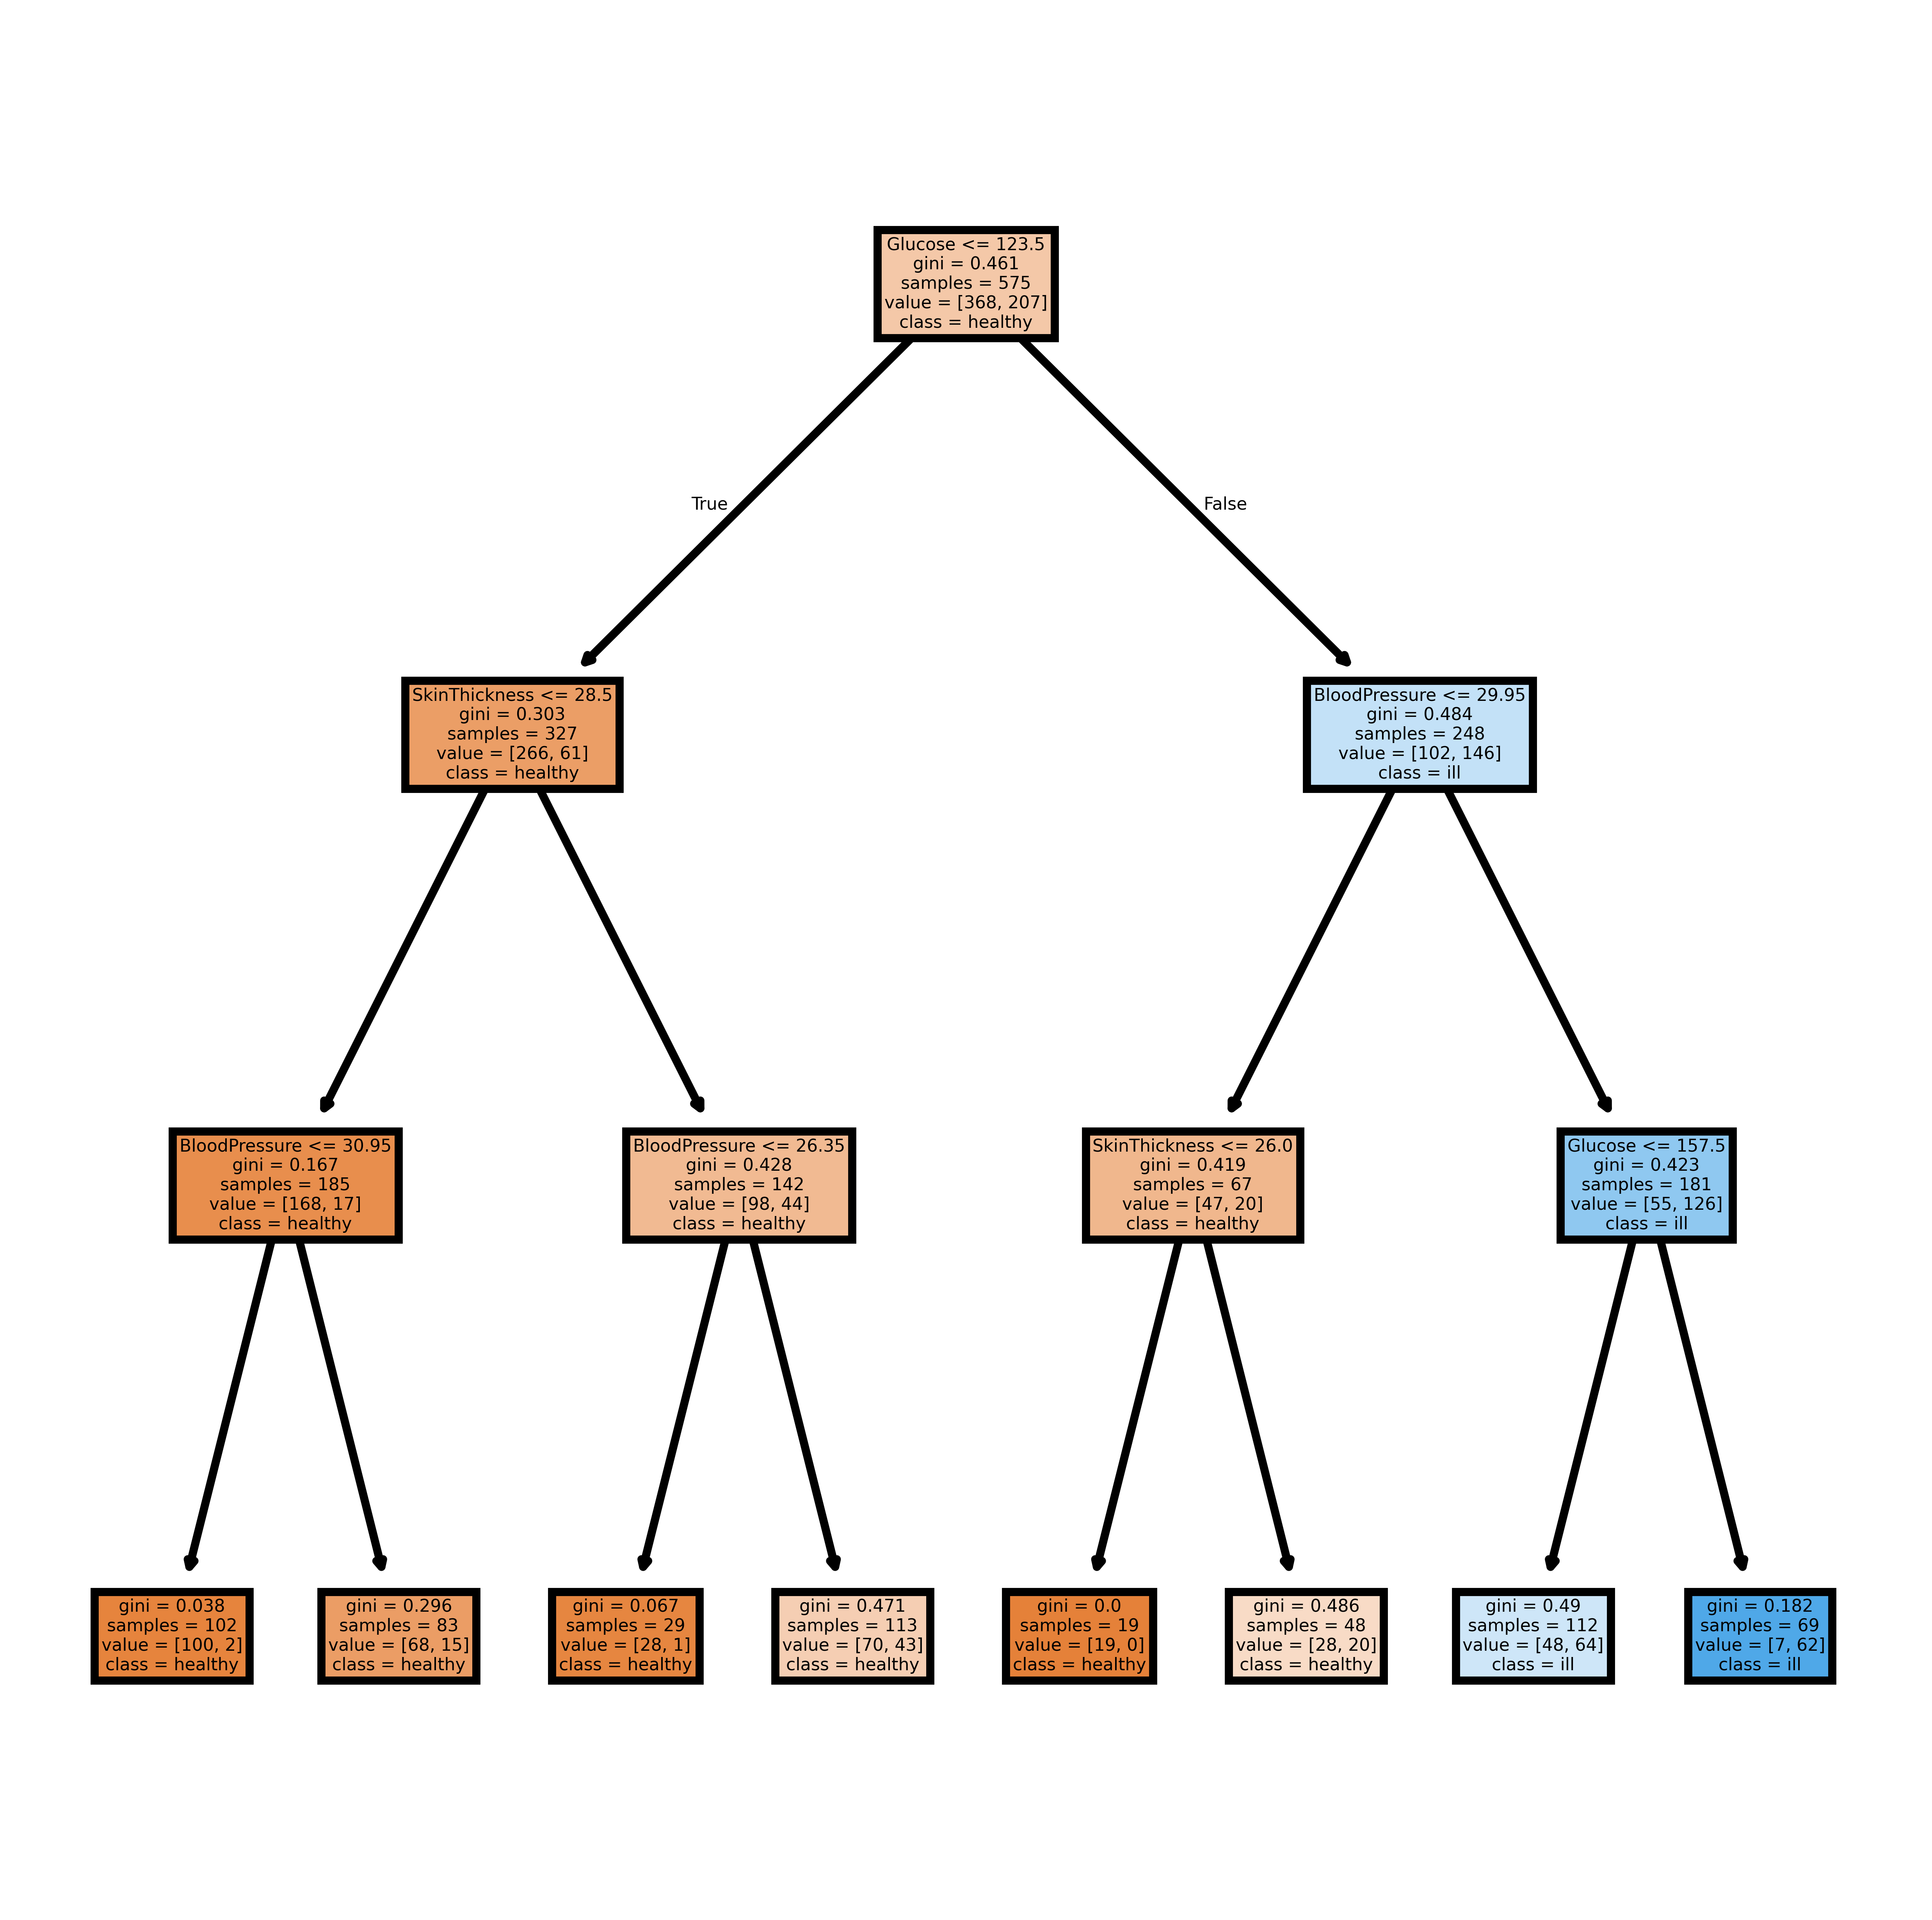

In [4]:
import matplotlib.pyplot as plt
# fn=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
fn=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
cn=['healthy','ill']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=1500)
tree.plot_tree(clf, feature_names = fn, class_names=cn, filled = True)
fig.savefig('imagename.png')

In [5]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

cn = confusion_matrix(Y_test, clf.predict(X_test))
print(cn)
print('Acc=', accuracy_score(Y_test, clf.predict(X_test)))
print('Pre=', precision_score(Y_test, clf.predict(X_test)))
print('Recall=', recall_score(Y_test, clf.predict(X_test)))
print('f1=', confusion_matrix(Y_test, clf.predict(X_test)))

[[115  16]
 [ 29  32]]
Acc= 0.765625
Pre= 0.6666666666666666
Recall= 0.5245901639344263
f1= [[115  16]
 [ 29  32]]
